# Week 3 - Day 4: Trees, Forests, SVM & k-NN

In this session, multiple classification models are trained and compared using the same dataset and train/test split.

The models used are:
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- k-Nearest Neighbors (k-NN)

The models are evaluated using the F1-score to compare their performance fairly.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt

data = load_breast_cancer()

X = data.data

# 1 = Malignant
# 0 = Benign
y = (data.target == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


## Decision Tree

A Decision Tree classifies samples using a sequence of feature-based conditions.

At each node, the model selects a feature and threshold that produce a better separation between the classes.

Gini impurity measures how mixed the classes are inside a node. Lower Gini values indicate purer nodes.

The tree depth is limited to reduce overfitting.

In [2]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print(f1_score(y_test, y_pred))

0.8860759493670886


### Decision Tree Visualization

The Decision Tree can be interpreted by following the conditions from the root node toward the final prediction.

Each node shows:
- The feature and threshold used for the split.
- `gini`: the impurity of the node.
- `samples`: the number of samples reaching the node.
- `value`: the class distribution.
- `class`: the majority class.

Only the first levels are displayed to keep the tree readable.

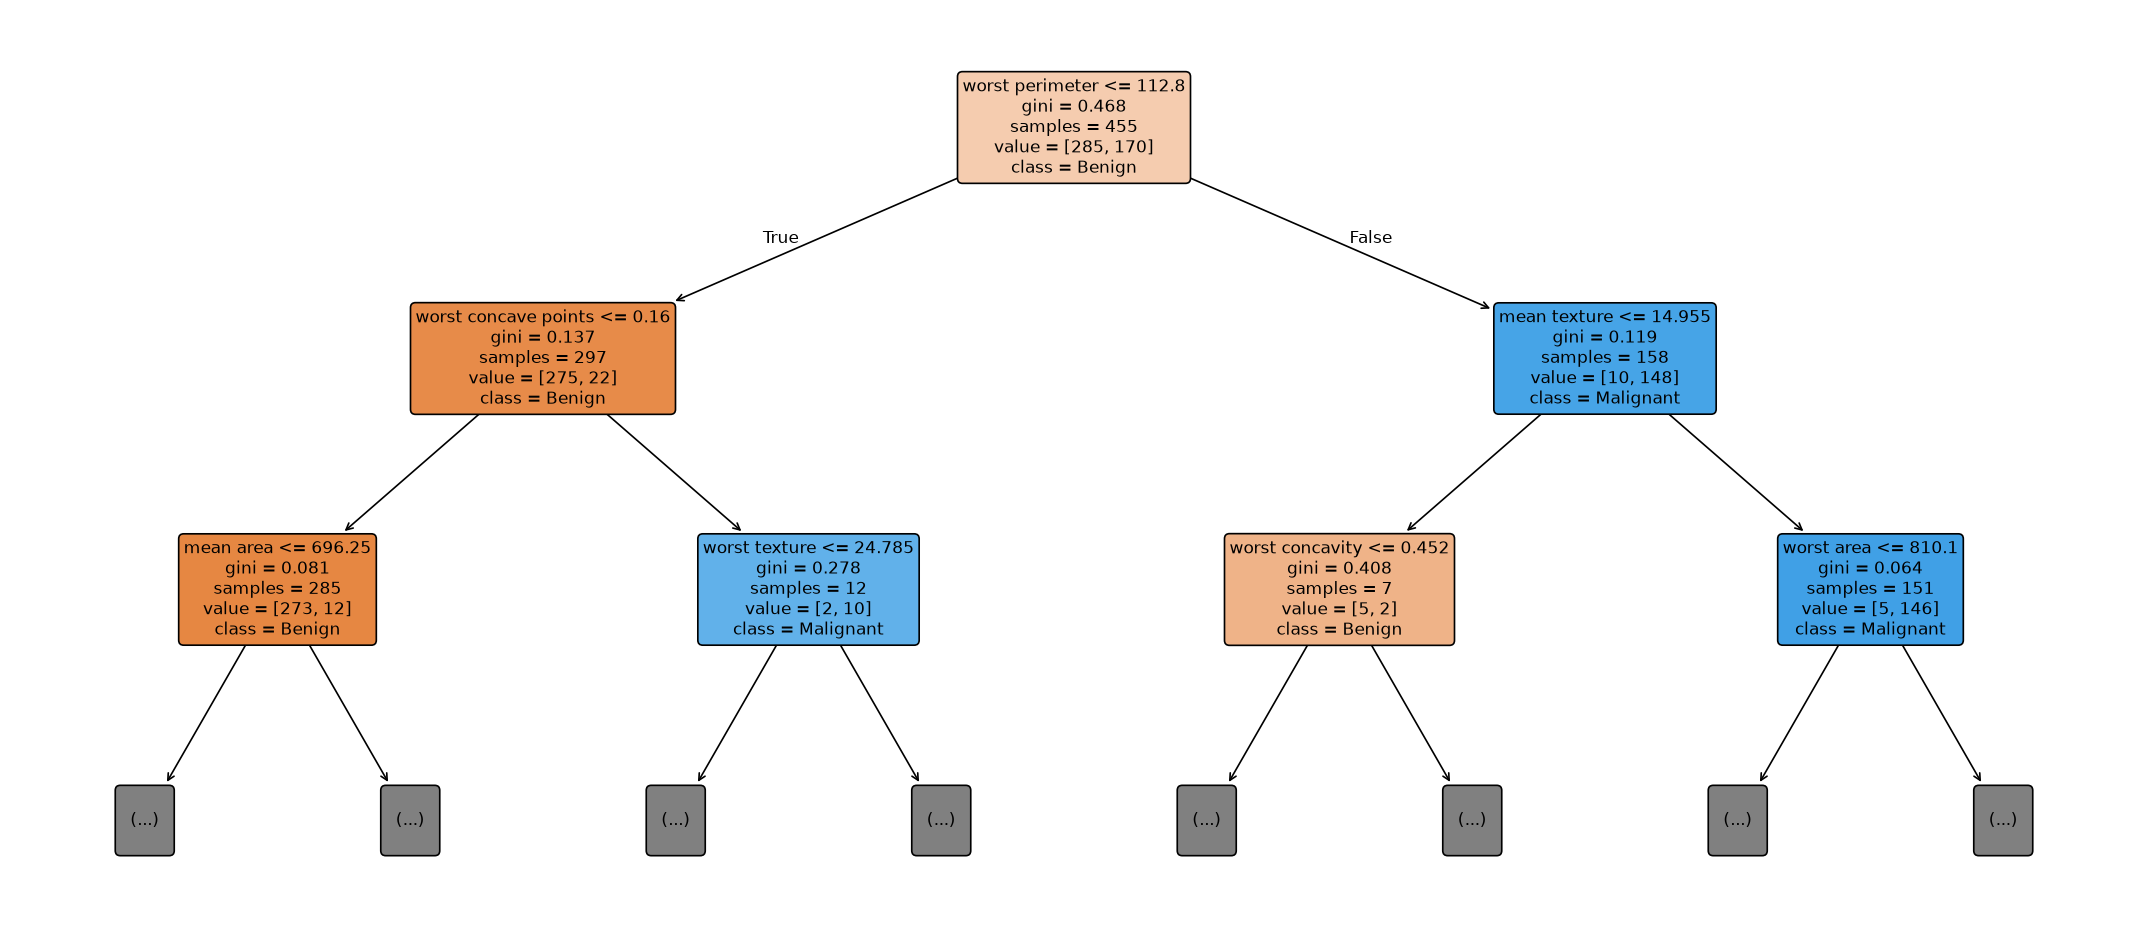

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8), dpi=120)

plot_tree(
    tree_model,
    feature_names=data.feature_names,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=10
)

plt.tight_layout()
plt.show()

### Decision Tree Generalization

The model is evaluated on both the training and testing data to observe its ability to generalize.

A large difference between training and testing performance can indicate overfitting.

In [6]:
y_train_pred = tree_model.predict(X_train)
y_test_pred = tree_model.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Train F1:", train_f1)
print("Test F1 :", test_f1)

Train F1: 0.9821428571428571
Test F1 : 0.8860759493670886


### Decision Tree Observation

The Decision Tree achieved:

- Train F1 ≈ 0.982
- Test F1 ≈ 0.886

The model performs better on the training data than on unseen testing data.

This shows the tendency of a single Decision Tree to learn specific patterns from the training data and become more sensitive to overfitting.

## Random Forest

Random Forest combines many Decision Trees instead of depending on a single tree.

The trees are made different using randomness in the training samples and the features considered during splitting.

The final classification is produced by combining the predictions of the individual trees.

This usually reduces variance and improves generalization compared with a single Decision Tree.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rand_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rand_model.fit(X_train, y_train)

y_pred = rand_model.predict(X_test)

print(f1_score(y_test, y_pred))

0.9629629629629629


### Random Forest Generalization

The Random Forest is also evaluated on both training and testing data to compare its generalization with the single Decision Tree.

In [8]:
rf_train_pred = rand_model.predict(X_train)
rf_test_pred = rand_model.predict(X_test)

print(
    "Random Forest Train F1:",
    f1_score(y_train, rf_train_pred)
)

print(
    "Random Forest Test F1:",
    f1_score(y_test, rf_test_pred)
)

Random Forest Train F1: 1.0
Random Forest Test F1: 0.9629629629629629


### Random Forest Observation

The Random Forest achieved:

- Train F1 = 1.000
- Test F1 ≈ 0.963

Although the model perfectly classified the training data, its testing performance remained very strong.

Compared with the single Decision Tree, Random Forest achieved better performance on unseen data and a smaller train-test performance gap.

### Random Forest Feature Importance

Random Forest can estimate the relative importance of the input features.

Feature importance represents how useful each feature was for the model when creating splits and reducing impurity across the trees.

The features are ranked from highest to lowest importance.

In [9]:
feature_importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": rand_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
23            worst area    0.151412
27  worst concave points    0.126497
20          worst radius    0.093475
22       worst perimeter    0.083642
7    mean concave points    0.081082
2         mean perimeter    0.077126
0            mean radius    0.061990
6         mean concavity    0.050818
3              mean area    0.045916
26       worst concavity    0.030022


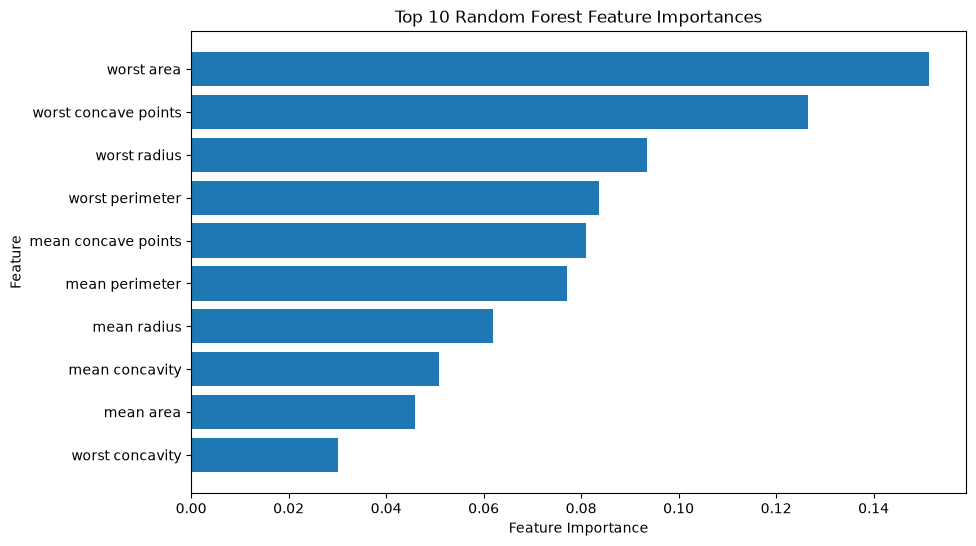

In [10]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.show()

### Feature Importance Observation

The most important features include:

- `worst area`
- `worst concave points`
- `worst radius`
- `worst perimeter`
- `mean concave points`

These features contributed strongly to the predictions made by the Random Forest.

Feature importance represents predictive importance, not causation. A feature may strongly help the model distinguish between classes without necessarily being a direct cause of the medical condition.

## Support Vector Machine (SVM)

SVM searches for a decision boundary that separates the classes while maximizing the margin between them.

The samples closest to this boundary are called Support Vectors.

SVM is sensitive to the numerical scale of the features, so feature scaling is applied before training.

### Feature Scaling

The features in the dataset have different numerical ranges.

Because SVM depends on the geometry of the feature space, features with large numerical values can dominate features with smaller values.

`StandardScaler` is fitted only on the training data and the same transformation is then applied to the testing data.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.svm import SVC

SVC_model = SVC(
    kernel='rbf'
)

SVC_model.fit(X_train_scaled, y_train)

y_pred = SVC_model.predict(X_test_scaled)

print(f1_score(y_test, y_pred))

0.9629629629629629


### Effect of Scaling

SVM performance improved significantly after scaling the features.

- Without Scaling: F1 ≈ 0.849
- With Scaling: F1 ≈ 0.963

This demonstrates the importance of feature scaling for models that depend on distances and the geometry of the feature space.

### Linear vs RBF Kernel

A Linear SVM attempts to separate the classes using a linear decision boundary.

The RBF kernel allows SVM to create more flexible non-linear decision boundaries.

Both kernels are tested using the same scaled training and testing data.

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

svm_linear = SVC(kernel="linear")
svm_rbf = SVC(kernel="rbf")

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

linear_pred = svm_linear.predict(X_test_scaled)
rbf_pred = svm_rbf.predict(X_test_scaled)

print(
    "Linear SVM F1:",
    f1_score(y_test, linear_pred)
)

print(
    "RBF SVM F1:",
    f1_score(y_test, rbf_pred)
)

Linear SVM F1: 0.95
RBF SVM F1: 0.9629629629629629


### Kernel Comparison

The results were:

- Linear SVM F1 = 0.950
- RBF SVM F1 ≈ 0.963

Both models performed strongly.

The Linear SVM result indicates that the classes can already be separated reasonably well using a linear boundary.

The slightly higher RBF result suggests that allowing a non-linear decision boundary provides additional useful flexibility for this dataset.

## k-Nearest Neighbors (k-NN)

k-NN classifies a new sample according to the classes of its nearest training samples.

For `k = 5`, the five closest samples vote on the final classification.

Because k-NN directly depends on distances between samples, scaled data is used.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

print(f1_score(y_test, y_pred))

0.9382716049382716


### Effect of k

The value of `k` determines how many neighboring samples participate in the prediction.

A very small value of `k` makes the model more sensitive to individual samples and noise.

A very large value produces smoother decisions but may ignore useful local patterns.

Several values are tested to observe this behavior.

In [15]:
for k in [1, 3, 5, 7, 11, 21]:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    pred = model.predict(
        X_test_scaled
    )

    score = f1_score(
        y_test,
        pred
    )

    print(
        "k =", k,
        "F1 =", score
    )

k = 1 F1 = 0.9024390243902439
k = 3 F1 = 0.9113924050632911
k = 5 F1 = 0.9382716049382716
k = 7 F1 = 0.9382716049382716
k = 11 F1 = 0.925
k = 21 F1 = 0.9113924050632911


### k-NN Observation

The tested values produced:

| k | F1-score |
|---:|---:|
| 1 | 0.902 |
| 3 | 0.911 |
| 5 | 0.938 |
| 7 | 0.938 |
| 11 | 0.925 |
| 21 | 0.911 |

The performance improved from `k = 1` until `k = 5` and `k = 7`, then started decreasing as the neighborhood became larger.

This demonstrates the balance between very local decisions and excessive smoothing.

In a real machine learning workflow, the final value of `k` should be selected using validation data or cross-validation rather than the final test set.

## Model Comparison

All models are evaluated using:

- The same dataset.
- The same train/test split.
- The same target definition.
- The same F1-score metric.

Using the same evaluation conditions makes the comparison between the classifiers fair.

In [16]:
results = {
    "Decision Tree": f1_score(
        y_test,
        tree_model.predict(X_test)
    ),

    "Random Forest": f1_score(
        y_test,
        rand_model.predict(X_test)
    ),

    "SVM": f1_score(
        y_test,
        SVC_model.predict(X_test_scaled)
    ),

    "k-NN": f1_score(
        y_test,
        knn_model.predict(X_test_scaled)
    )
}

comparison = pd.DataFrame(
    results.items(),
    columns=["Model", "F1 Score"]
)

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

print(comparison)

           Model  F1 Score
1  Random Forest  0.962963
2            SVM  0.962963
3           k-NN  0.938272
0  Decision Tree  0.886076


### Final Results

| Model | F1-score |
|---|---:|
| Random Forest | 0.963 |
| RBF SVM | 0.963 |
| k-NN | 0.938 |
| Decision Tree | 0.886 |

Random Forest and RBF-SVM achieved the highest F1-score on this train/test split.

Although they achieved similar performance, they use very different approaches.

- Random Forest combines predictions from many different Decision Trees.
- SVM searches for a strong decision boundary between the classes.
- k-NN classifies samples according to nearby training examples.
- Decision Tree uses a sequence of interpretable rules.

## Key Observations

### Decision Tree
- Easy to interpret.
- Uses feature-based rules.
- Does not normally require feature scaling.
- Can easily overfit.

### Random Forest
- Combines many randomized Decision Trees.
- Generalizes better than a single tree in this experiment.
- Does not normally require feature scaling.
- Provides feature importance information.

### SVM
- Finds a decision boundary with a large margin.
- Support Vectors help determine the boundary.
- RBF can model non-linear relationships.
- Feature scaling is important.

### k-NN
- Uses nearby training samples to classify new samples.
- Simple and intuitive.
- Feature scaling is important.
- The value of `k` strongly affects model behavior.

## Conclusion

Four classification algorithms were trained and evaluated on the Breast Cancer Wisconsin dataset.

The Decision Tree provided the clearest interpretation but showed a larger difference between training and testing performance.

Random Forest improved the test performance by combining many diverse trees and also provided information about the most influential features.

SVM achieved strong performance after feature scaling, with the RBF kernel slightly outperforming the linear kernel.

k-NN also performed well after scaling, and testing different values of `k` demonstrated the effect of neighborhood size on model performance.

The results show that there is no single model that is always best. Different algorithms should be evaluated fairly, and the final model should be selected according to predictive performance, generalization, computational requirements, and interpretability.